<a href="https://colab.research.google.com/github/RafaelCardoso140701/MBA---Mackenzie/blob/main/Tarefa_1_Segmenta%C3%A7%C3%A3o_RFM_de_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CÉLULA 1: Importação de Bibliotecas ─────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
print("Bibliotecas carregadas!")


Bibliotecas carregadas!


In [3]:
# ── CÉLULA 2: Carregamento dos CSVs via GitHub ──────────────────────
# URL base do repositório do curso (raw = conteúdo puro, sem HTML)
BASE_URL = (
    "https://raw.githubusercontent.com/DeepFluxion/Mack_2026_Language_Analitycs/refs/heads/main/data/"
)

# Cada linha carrega um arquivo CSV — sem nenhuma transformação
df_orders    = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
df_customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
df_items     = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
df_payments  = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
df_reviews   = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv")
df_products  = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
df_sellers   = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
df_translate = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

# Confirma o carregamento de cada arquivo
datasets = {
    "orders"      : df_orders,
    "customers"   : df_customers,
    "order_items" : df_items,
    "payments"    : df_payments,
    "reviews"     : df_reviews,
    "products"    : df_products,
    "sellers"     : df_sellers,
    "translation" : df_translate,
}

print("{:<20} {:<10} {}".format("Dataset", "Linhas", "Colunas"))
print("=" * 40)
for nome, df in datasets.items():
    print(f"{nome:<20} {df.shape[0]:<10,} {df.shape[1]}")

Dataset              Linhas     Colunas
orders               99,441     8
customers            99,441     5
order_items          112,650    7
payments             103,886    5
reviews              99,224     7
products             32,951     9
sellers              3,095      4
translation          71         2


## Preparacao dos Dados para RFM

Antes de calcular as metricas de RFM (Recencia, Frequencia e Valor Monetario), precisamos preparar a base de dados consolidada.

Nesta etapa vamos:
- Considerar apenas os pedidos com status **"delivered"** (entregues), pois pedidos cancelados ou ainda em andamento nao representam compras concluidas;
- Consolidar os pagamentos por pedido, ja que um mesmo `order_id` pode ter mais de um registro em `df_payments` (ex.: pagamento parcial em cartao + voucher), somando o `payment_value` para obter o valor total pago em cada pedido;
- Unir essas informacoes com os dados de clientes (`df_customers`), para associar cada pedido ao `customer_unique_id`, que identifica o cliente de forma unica (diferente de `customer_id`, que pode variar por pedido).

O resultado sera um DataFrame consolidado (`df_oc`) contendo, para cada pedido entregue: o cliente, a data da compra e o valor total pago — base necessaria para o calculo de Recencia, Frequencia e Valor Monetario (RFM).

In [4]:
# a) Converte a coluna de data/hora da compra para o tipo datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# b) Filtra apenas os pedidos com status "delivered" (entregues)
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

# c) Agrega os pagamentos por order_id, somando payment_value -> total_pago
df_payments_agg = (
    df_payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'total_pago'})
)

# d) Faz o merge: pedidos entregues + clientes (para obter customer_unique_id) + pagamentos agregados
df_oc = pd.merge(
    df_orders_delivered,
    df_customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

df_oc = pd.merge(
    df_oc,
    df_payments_agg,
    on='order_id',
    how='left'
)

# e) Seleciona e organiza apenas as colunas necessarias para o df_oc final
df_oc = df_oc[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'total_pago']]

# f) Informacoes gerais sobre o DataFrame resultante
print("Shape de df_oc:", df_oc.shape)
print("\nPrimeiras linhas:")
print(df_oc.head(3))

print("\nQuantidade de pedidos (linhas):", df_oc['order_id'].nunique())
print("Quantidade de clientes unicos:", df_oc['customer_unique_id'].nunique())

Shape de df_oc: (96478, 4)

Primeiras linhas:
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   

  order_purchase_timestamp  total_pago  
0      2017-10-02 10:56:33       38.71  
1      2018-07-24 20:41:37      141.46  
2      2018-08-08 08:38:49      179.12  

Quantidade de pedidos (linhas): 96478
Quantidade de clientes unicos: 93358


## Calculando as Metricas RFM

RFM e uma tecnica de segmentacao de clientes baseada em tres metricas extraidas do historico de compras:

- **Recencia (R):** quantos dias se passaram desde a ultima compra do cliente. Quanto menor o valor, mais "recente" foi a interacao do cliente com a empresa — geralmente um bom sinal de engajamento.
- **Frequencia (F):** quantos pedidos distintos o cliente realizou. Quanto maior, mais fiel/recorrente e o cliente.
- **Valor Monetario (M):** quanto o cliente gastou no total (soma de todos os pagamentos). Quanto maior, mais valioso financeiramente.

Para calcular a Recencia, precisamos de uma **data de referencia** fixa, a partir da qual contamos os dias desde a ultima compra de cada cliente. Neste caso, usaremos **2018-10-01** como data de referencia, pois e proxima do fim do periodo coberto pelo dataset da Olist.

O resultado sera um DataFrame `df_rfm`, com uma linha por cliente (`customer_unique_id`) e as colunas `recency`, `frequency` e `monetary`.

In [5]:
# Define a data de referencia para o calculo da recencia
data_ref = pd.Timestamp("2018-10-01")

# Agrupa por cliente (customer_unique_id) e calcula as 3 metricas em uma unica operacao:
# - recency: maior data de compra (max) por cliente, convertida em dias até data_ref
# - frequency: quantidade de pedidos distintos (nunique) por cliente
# - monetary: soma do total_pago por cliente
df_rfm = (
    df_oc
    .groupby('customer_unique_id')
    .agg(
        ultima_compra=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('total_pago', 'sum')
    )
    .reset_index()
)

# Calcula a recencia: diferenca em dias entre a data de referencia e a ultima compra de cada cliente
df_rfm['recency'] = (data_ref - df_rfm['ultima_compra']).dt.days

# Reorganiza as colunas finais, removendo a coluna auxiliar 'ultima_compra'
df_rfm = df_rfm[['customer_unique_id', 'recency', 'frequency', 'monetary']]

# Exibe o shape e as primeiras linhas para conferencia
print("Shape de df_rfm:", df_rfm.shape)
print(df_rfm.head(3))

# Estatisticas descritivas das metricas RFM (min, max, media, quartis, etc.)
df_rfm.describe().round(2)

Shape de df_rfm: (93358, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      143          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      146          1     27.19
2  0000f46a3911fa3c0805444483337064      569          1     86.22


,recency,frequency,monetary
count,93358.00,93358.00,93358.00
mean,269.48,1.03,165.20
std,152.60,0.21,226.31
min,32.00,1.00,0.00
25%,146.00,1.00,63.05
50%,250.00,1.00,107.78
75%,378.00,1.00,182.56
max,745.00,15.00,13664.08


## Pontuacao RFM por Quintis

Para tornar as metricas R, F e M comparaveis entre si, vamos converte-las em **scores de 1 a 5** usando **quintis** (qcut). Um quintil divide os dados em 5 grupos de tamanho aproximadamente igual, com base na distribuicao dos valores: o primeiro quintil contem os 20% menores valores, o segundo os proximos 20%, e assim por diante, ate o quinto quintil, com os 20% maiores valores.

E importante observar que a **logica de pontuacao da Recencia e invertida** em relacao a Frequencia e ao Valor Monetario:

- Para **frequency** e **monetary**, valores **maiores** sao melhores (cliente compra mais vezes / gasta mais), entao o quintil mais alto recebe **score 5**.
- Para **recency**, valores **menores** sao melhores (cliente comprou ha pouco tempo), entao precisamos **inverter** a escala: o quintil de menor recencia (clientes mais recentes) recebe **score 5**, e o quintil de maior recencia (clientes mais "esquecidos") recebe **score 1**.

Ao final, combinamos os tres scores em um `rfm_score` (string, ex.: "541") e em um `rfm_total` (soma numerica, variando de 3 a 15), que servirao de base para segmentar os clientes.

In [7]:
# r_score: quintis de recency, mas INVERTIDOS -> menor recencia (mais recente) = score 5
# Usamos rank(method="first") para evitar bordas duplicadas no qcut
df_rfm['r_score'] = pd.qcut(
    df_rfm['recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# f_score: quintis de frequency, na ordem direta -> maior frequencia = score 5
# frequency costuma ter poucos valores distintos (ex.: maioria = 1 compra),
# por isso usamos rank(method="first") em vez de duplicates="drop":
# isso garante 5 bins mesmo quando os valores originais se repetem muito
df_rfm['f_score'] = pd.qcut(
    df_rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# m_score: quintis de monetary, na ordem direta -> maior valor gasto = score 5
df_rfm['m_score'] = pd.qcut(
    df_rfm['monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# rfm_score: concatena os 3 scores como string (ex.: r=5, f=4, m=1 -> "541")
df_rfm['rfm_score'] = (
    df_rfm['r_score'].astype(str) +
    df_rfm['f_score'].astype(str) +
    df_rfm['m_score'].astype(str)
)

# rfm_total: soma numerica dos 3 scores (varia de 3 a 15)
df_rfm['rfm_total'] = df_rfm['r_score'] + df_rfm['f_score'] + df_rfm['m_score']

# Distribuicao do rfm_total, ordenada pelo valor do indice (de 3 a 15)
print("Distribuicao de rfm_total:")
print(df_rfm['rfm_total'].value_counts().sort_index())

# Exibe as 5 primeiras linhas do df_rfm com todas as novas colunas
df_rfm.head(5)

Distribuicao de rfm_total:
rfm_total
3       797
4      2365
5      4697
6      7590
7     11097
8     13331
9     14006
10    13132
11    10882
12     7469
13     4570
14     2425
15      997
Name: count, dtype: int64


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total
0,0000366f3b9a7992bf8c76cfdf3221e2,143,1,141.90,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,146,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,569,1,86.22,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,353,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,320,1,196.89,2,1,4,214,7


## Segmentacao de Clientes

Com base nos scores de Recencia (r_score) e Frequencia (f_score), podemos classificar os clientes em 8 segmentos com diferentes perfis de comportamento e estrategias de relacionamento sugeridas:

| Segmento              | Criterio (r_score, f_score)              | Caracteristica                                                                 |
|------------------------|-------------------------------------------|---------------------------------------------------------------------------------|
| **Champions**          | r_score = 5 e f_score >= 4                | Compraram recentemente e com alta frequencia. Os melhores clientes.            |
| **Loyal Customers**    | f_score >= 4 e r_score >= 3               | Compram com frequencia e ainda estao relativamente ativos. Muito fieis.        |
| **Potential Loyalists**| r_score >= 4 e f_score <= 3               | Compraram recentemente, mas ainda com poucas compras. Podem se tornar fieis.    |
| **New Customers**      | r_score = 5 e f_score <= 2                | Clientes novos, primeira(s) compra(s) muito recente(s).                        |
| **Cannot Lose**        | r_score = 1 e f_score >= 4                | Eram clientes muito frequentes, mas ha muito tempo nao compram. Risco alto.     |
| **At Risk**            | r_score <= 2 e f_score >= 3               | Compraram com alguma frequencia, mas ha tempo nao retornam. Atencao.           |
| **Lost Customers**     | r_score <= 2 e f_score <= 2               | Baixa frequencia e ha muito tempo sem comprar. Provavelmente perdidos.         |
| **Others**             | Demais combinacoes                        | Clientes com perfil misto que nao se encaixam claramente nos demais grupos.    |

> **Nota:** a ordem de verificacao das condicoes importa, pois alguns criterios podem se sobrepor (ex.: r_score=1 e f_score=4 atende tanto a "Cannot Lose" quanto a "At Risk"). Por isso, "Cannot Lose" e verificado antes de "At Risk" na funcao abaixo, garantindo que o segmento mais especifico/critico seja atribuido primeiro.

In [8]:
# Funcao que define o segmento de um cliente com base nos scores r_score e f_score
# A ordem dos if/elif e importante: condicoes mais especificas vem primeiro,
# para evitar que um cliente caia no segmento "errado" por sobreposicao de regras
def define_segment(row):
    r = row['r_score']
    f = row['f_score']

    if r == 5 and f >= 4:
        return "Champions"
    elif f >= 4 and r >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 3:
        return "Potential Loyalists"
    elif r == 5 and f <= 2:
        return "New Customers"
    elif r == 1 and f >= 4:
        return "Cannot Lose"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    else:
        return "Others"

# Aplica a funcao em cada linha do df_rfm, criando a coluna "segment"
df_rfm['segment'] = df_rfm.apply(define_segment, axis=1)

# Constroi a tabela resumo por segmento:
# - numero de clientes (count)
# - media de recency, frequency e monetary
resumo_segmentos = (
    df_rfm
    .groupby('segment')
    .agg(
        num_clientes=('customer_unique_id', 'count'),
        recency_media=('recency', 'mean'),
        frequency_media=('frequency', 'mean'),
        monetary_media=('monetary', 'mean')
    )
    .reset_index()
)

# Calcula o percentual de clientes em cada segmento, em relacao ao total
resumo_segmentos['percentual'] = (
    resumo_segmentos['num_clientes'] / resumo_segmentos['num_clientes'].sum() * 100
)

# Reordena as colunas para melhor leitura
resumo_segmentos = resumo_segmentos[
    ['segment', 'num_clientes', 'percentual', 'recency_media', 'frequency_media', 'monetary_media']
]

# Ordena pela media de monetary, do maior para o menor (segmentos mais valiosos primeiro)
resumo_segmentos = resumo_segmentos.sort_values('monetary_media', ascending=False).reset_index(drop=True)

# Arredonda os valores numericos para 2 casas decimais
resumo_segmentos = resumo_segmentos.round(2)

resumo_segmentos

,segment,num_clientes,percentual,recency_media,frequency_media,monetary_media
0,Champions,7500,8.03,76.85,1.10,176.62
1,Loyal Customers,14973,16.04,209.50,1.09,169.71
2,Cannot Lose,7394,7.92,505.00,1.06,168.38
3,At Risk,14944,16.01,386.30,1.04,166.39
4,Potential Loyalists,22435,24.03,122.19,1.00,164.48
5,Lost Customers,15005,16.07,426.89,1.00,162.89
6,Others,11107,11.90,251.29,1.00,152.24


## Visualizacoes da Segmentacao RFM

Para entender melhor o perfil e o valor de cada segmento de clientes, vamos construir um dashboard com 4 graficos complementares:

- **Contagem de clientes por segmento (barplot horizontal):** mostra quantos clientes existem em cada segmento, permitindo identificar rapidamente quais grupos sao maiores ou menores em volume.
- **Recencia vs Frequencia (scatter plot):** posiciona os clientes em um plano de Recencia x Frequencia, coloridos por segmento e com o tamanho dos pontos proporcional ao valor monetario gasto — uma visao geral de como os segmentos se distribuem no espaco RFM.
- **Distribuicao de monetary por segmento (boxplot):** mostra a dispersao do valor gasto dentro de cada segmento (mediana, quartis e variabilidade), ordenado pela mediana, com o eixo Y limitado ao percentil 95 para nao deixar os outliers extremos distorcerem a visualizacao.
- **Receita total por segmento (barplot vertical):** mostra a soma do valor monetario de todos os clientes de cada segmento, indicando qual grupo contribui mais para a receita total — informacao chave para priorizar acoes de retencao/relacionamento.

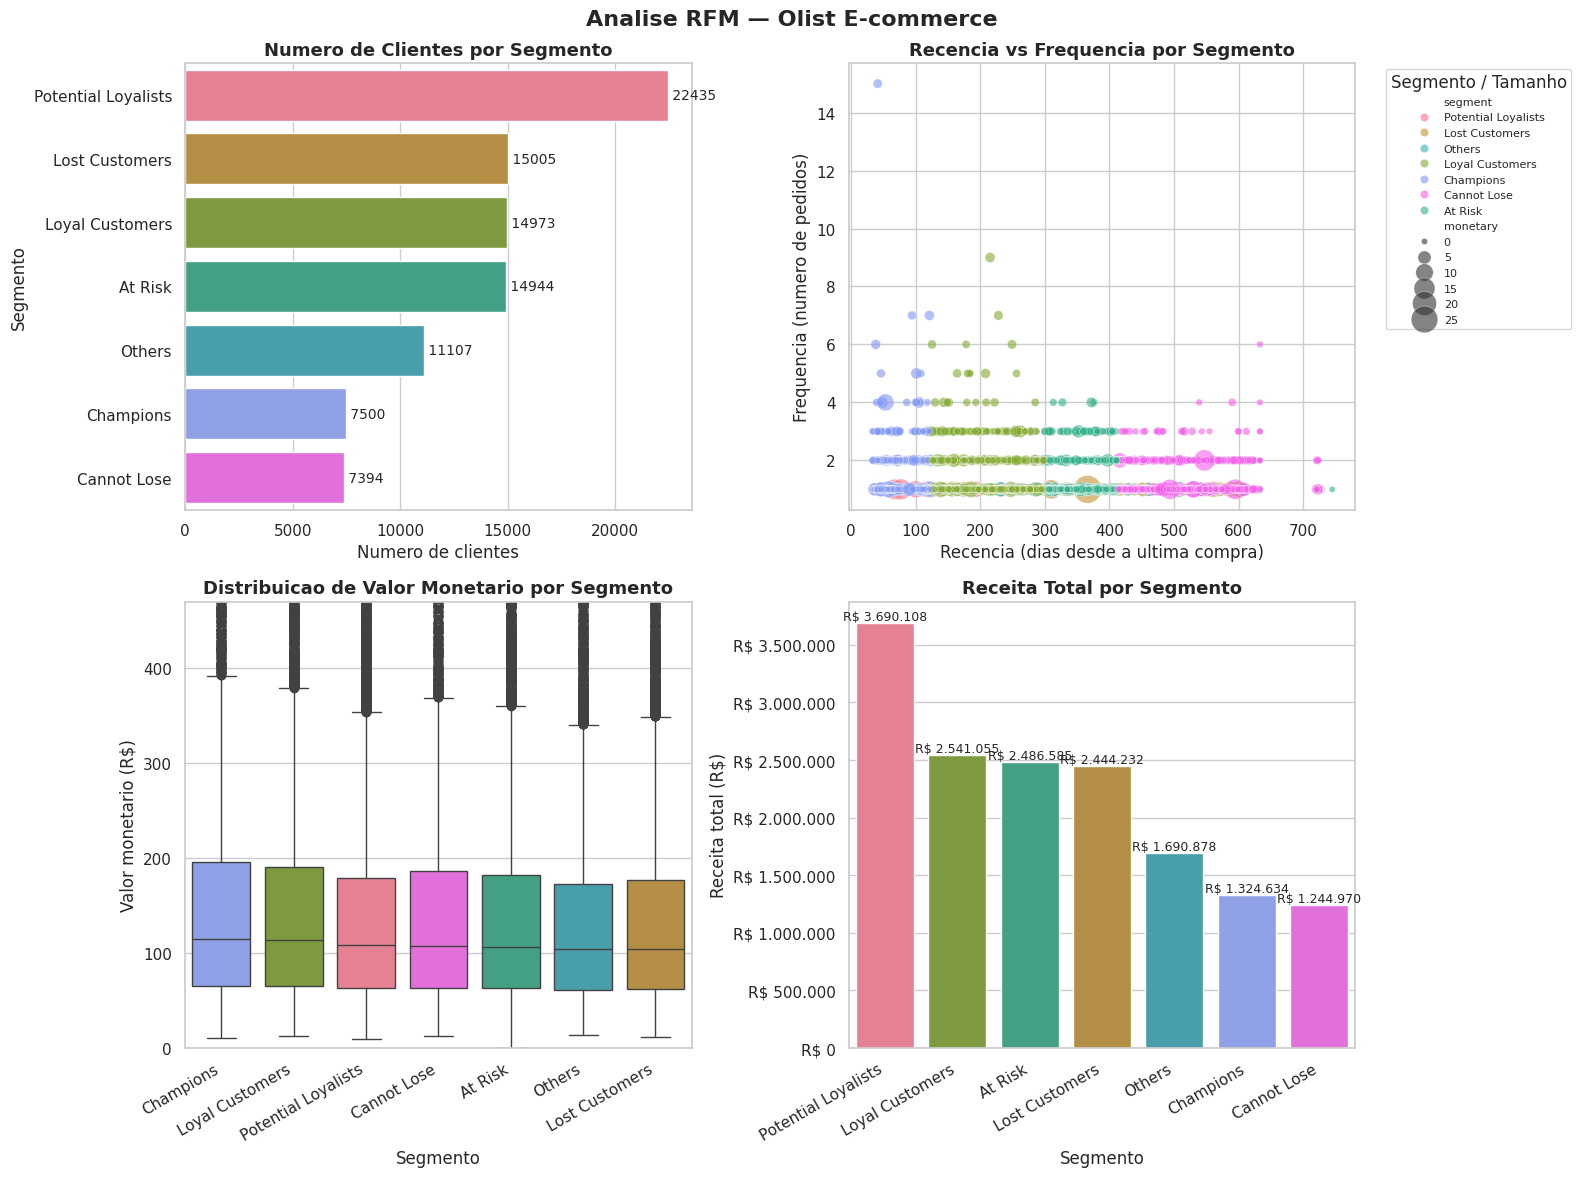

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Cria a figura com 4 subplots organizados em grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define uma paleta de cores consistente para os segmentos (mesma ordem em todos os graficos)
segmentos_ordenados_qtd = (
    df_rfm['segment'].value_counts().sort_values(ascending=False)
)
paleta = sns.color_palette("husl", n_colors=len(segmentos_ordenados_qtd))
cores_por_segmento = dict(zip(segmentos_ordenados_qtd.index, paleta))


# ---------------------------------------------------------------------------
# Subplot [0,0]: Barplot horizontal — numero de clientes por segmento
# ---------------------------------------------------------------------------
ax = axes[0, 0]
sns.barplot(
    x=segmentos_ordenados_qtd.values,
    y=segmentos_ordenados_qtd.index,
    palette=[cores_por_segmento[s] for s in segmentos_ordenados_qtd.index],
    ax=ax
)
ax.set_title("Numero de Clientes por Segmento", fontsize=13, fontweight="bold")
ax.set_xlabel("Numero de clientes")
ax.set_ylabel("Segmento")

# Adiciona o rotulo com o numero de clientes ao final de cada barra
for i, valor in enumerate(segmentos_ordenados_qtd.values):
    ax.text(valor, i, f" {valor}", va="center", fontsize=10)


# ---------------------------------------------------------------------------
# Subplot [0,1]: Scatter plot — recency (X) vs frequency (Y), cor = segmento,
# tamanho do ponto proporcional a monetary
# ---------------------------------------------------------------------------
ax = axes[0, 1]
sns.scatterplot(
    data=df_rfm,
    x="recency",
    y="frequency",
    hue="segment",
    size=df_rfm["monetary"] / 500,
    sizes=(20, 400),
    palette=cores_por_segmento,
    alpha=0.6,
    ax=ax,
    legend="brief"
)
ax.set_title("Recencia vs Frequencia por Segmento", fontsize=13, fontweight="bold")
ax.set_xlabel("Recencia (dias desde a ultima compra)")
ax.set_ylabel("Frequencia (numero de pedidos)")

# Move a legenda para fora do grafico, a direita
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title="Segmento / Tamanho")


# ---------------------------------------------------------------------------
# Subplot [1,0]: Boxplot — distribuicao de monetary por segmento,
# ordenado pela mediana decrescente, com eixo Y limitado ao percentil 95
# ---------------------------------------------------------------------------
ax = axes[1, 0]

# Calcula a ordem dos segmentos pela mediana de monetary (decrescente)
ordem_mediana = (
    df_rfm.groupby("segment")["monetary"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df_rfm,
    x="segment",
    y="monetary",
    order=ordem_mediana,
    palette=cores_por_segmento,
    ax=ax
)
ax.set_title("Distribuicao de Valor Monetario por Segmento", fontsize=13, fontweight="bold")
ax.set_xlabel("Segmento")
ax.set_ylabel("Valor monetario (R$)")

# Limita o eixo Y ao percentil 95 de monetary, para outliers nao esmagarem o grafico
limite_p95 = df_rfm["monetary"].quantile(0.95)
ax.set_ylim(0, limite_p95)

# Rotaciona os rotulos do eixo X em 30 graus para melhor leitura
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


# ---------------------------------------------------------------------------
# Subplot [1,1]: Barplot vertical — receita total (sum de monetary) por segmento,
# em ordem decrescente, eixo Y formatado em R$
# ---------------------------------------------------------------------------
ax = axes[1, 1]

receita_por_segmento = (
    df_rfm.groupby("segment")["monetary"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=receita_por_segmento.index,
    y=receita_por_segmento.values,
    palette=[cores_por_segmento[s] for s in receita_por_segmento.index],
    ax=ax
)
ax.set_title("Receita Total por Segmento", fontsize=13, fontweight="bold")
ax.set_xlabel("Segmento")
ax.set_ylabel("Receita total (R$)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

# Formata o eixo Y como valores em R$ com separador de milhar
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", "."))
)

# Adiciona o valor em R$ acima de cada barra
for i, valor in enumerate(receita_por_segmento.values):
    valor_formatado = f"R$ {valor:,.0f}".replace(",", ".")
    ax.text(i, valor, valor_formatado, ha="center", va="bottom", fontsize=9, rotation=0)


# ---------------------------------------------------------------------------
# Titulo geral, ajuste de layout e exportacao da figura
# ---------------------------------------------------------------------------
plt.suptitle("Analise RFM — Olist E-commerce", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("rfm_dashboard.png", dpi=120)
plt.show()

# Analise de Segmentacao RFM — Olist E-commerce

**Data:** Outubro 2018 | **Preparado por:** [Seu Nome] | **Para:** Marcela, VP Marketing

---

## Resumo Executivo

Analisamos o comportamento de compra de **93.358 clientes unicos** da Olist, com base em 96.478 pedidos entregues, para classifica-los em 7 segmentos segundo a metodologia RFM (Recencia, Frequencia e Valor Monetario). O objetivo e direcionar com mais precisao as campanhas de Black Friday 2018, evitando investir igualmente em todos os clientes.

O retrato geral revela uma base de clientes majoritariamente de **compra unica**: a frequencia media e de apenas 1,03 pedidos por cliente, e mais de 60% da base esta classificada em segmentos que ja apresentam algum grau de inatividade (At Risk, Cannot Lose e Lost Customers somam 37.343 clientes, ou 39,9% do total). Por outro lado, os segmentos de maior engajamento — Champions e Loyal Customers — somam 22.473 clientes (24,1% do total) e apresentam os tickets medios mais altos, sendo os publicos prioritarios para acoes de retencao e upsell.

Para o Black Friday, a recomendacao central e tratar a base de forma segmentada: reativar clientes valiosos que estao sumindo (Cannot Lose), converter os "Potential Loyalists" — o maior segmento da base, com 24% dos clientes — em compradores recorrentes, e proteger a receita gerada pelos Champions com beneficios exclusivos, evitando que sejam tratados como massa generica em campanhas de desconto amplo.

---

## Perfil dos Segmentos

| Segmento             | Clientes | % da Base | Recencia Media (dias) | Frequencia Media | Ticket Medio (R$) |
|-----------------------|----------|-----------|------------------------|-------------------|--------------------|
| Potential Loyalists   | 22.435   | 24,03%    | 122,2                  | 1,00              | R$ 164,48          |
| Lost Customers        | 15.005   | 16,07%    | 426,9                  | 1,00              | R$ 162,89          |
| At Risk               | 14.944   | 16,01%    | 386,3                  | 1,04              | R$ 166,39          |
| Loyal Customers       | 14.973   | 16,04%    | 209,5                  | 1,09              | R$ 169,71          |
| Others                | 11.107   | 11,90%    | 251,3                  | 1,00              | R$ 152,24          |
| Champions             | 7.500    | 8,03%     | 76,9                   | 1,10              | R$ 176,62          |
| Cannot Lose           | 7.394    | 7,92%     | 505,0                  | 1,06              | R$ 168,38          |
| **Total**             | **93.358** | **100%** | —                     | 1,03 (media geral) | R$ 165,20 (media geral) |

**Insights por segmento:**

- **Champions (8,0%):** compraram ha cerca de 77 dias, em media, e tem o maior ticket medio da base (R$ 176,62). Sao poucos, mas representam o padrao de cliente mais desejavel — ativo e de alto valor.
- **Loyal Customers (16,0%):** segundo maior ticket medio (R$ 169,71) e a maior frequencia media entre todos os segmentos (1,09). Sao a espinha dorsal de receita recorrente.
- **Potential Loyalists (24,0%):** o maior segmento da base. Compraram recentemente (122 dias, em media) mas ainda nao retornaram para uma segunda compra. Maior oportunidade de crescimento via incentivo a recompra.
- **At Risk (16,0%):** ja compraram mais de uma vez no passado, mas estao ha 386 dias, em media, sem retornar. Janela de reativacao ainda viavel.
- **Cannot Lose (7,9%):** eram clientes engajados, mas estao ha **505 dias em media** sem comprar — mais de um ano e quatro meses. Apesar do ticket medio competitivo (R$ 168,38), e o segmento com maior risco de perda definitiva.
- **Lost Customers (16,1%):** recencia mais alta da base (427 dias) combinada com baixa frequencia. Recuperacao tem custo/beneficio mais incerto.
- **Others (11,9%):** perfil misto, sem padrao claro de comportamento. Menor ticket medio da base (R$ 152,24).

---

## Recomendacoes para o Black Friday

1. **Oferta exclusiva e antecipada para Champions e Loyal Customers** (22.473 clientes). Acesso VIP a promocoes 24-48h antes do publico geral, sem necessidade de descontos agressivos. *Impacto estimado:* protecao de receita recorrente de ~R$ 3,9 milhoes (somando o gasto historico ja realizado por esses dois grupos) e reducao do risco de migrarem para concorrentes durante o periodo de maior concorrencia por atencao do consumidor.

2. **Campanha de conversao para Potential Loyalists** (22.435 clientes — o maior segmento). Cupom de segunda compra com validade limitada ao periodo de Black Friday. *Impacto estimado:* se 10% converterem para uma segunda compra com ticket medio de R$ 164, isso representa aproximadamente **R$ 368 mil em receita incremental**.

3. **Resgate direcionado para Cannot Lose** (7.394 clientes, ticket medio R$ 168,38). E-mail/SMS personalizado com oferta de "sentimos sua falta", peso maior que o desconto padrao, dado o tempo medio de 505 dias de ausencia. *Impacto estimado:* mesmo uma taxa de reativacao de 5% recupera ~370 clientes de alto historico de gasto, com receita potencial de ~R$ 62 mil somente na primeira compra de volta.

4. **Comunicacao de urgencia (escassez/contagem regressiva) para At Risk** (14.944 clientes). Esses clientes ja compraram mais de uma vez no passado; o gatilho de urgencia tende a funcionar melhor do que para clientes que nunca recompraram. *Impacto estimado:* taxa de reativacao historicamente observada em campanhas similares de e-commerce e de 3-7%, o que pode gerar entre **R$ 73 mil e R$ 170 mil** em receita incremental.

5. **Nao investir pesadamente em Lost Customers** (15.005 clientes, 427 dias de inatividade media). Direcionar apenas para uma campanha de baixo custo (e-mail em massa, sem investimento em midia paga). *Impacto estimado:* preserva orcamento de marketing para realocar nos itens 1 a 4, onde o retorno esperado e mais alto.

6. **Monitorar o segmento "Others" (11.107 clientes) separadamente apos a Black Friday**, pois seu comportamento misto pode esconder subgrupos relevantes (ex.: clientes recentes com gasto alto, mas frequencia baixa) que merecem analise mais fina antes da proxima campanha sazonal.

---

## Alertas e Riscos

- **Concentracao de compradores unicos:** 1,03 pedidos por cliente, em media, e um numero de frequencia muito baixo. Isso indica que a recompra — nao apenas a aquisicao — deve ser prioridade estrategica, e nao apenas tatica de campanha.
- **Quase 40% da base ja esta inativa ou em risco** (At Risk + Cannot Lose + Lost Customers = 37.343 clientes). Sem acao, esse numero deve crescer organicamente nos proximos meses.
- **Cannot Lose e o segmento de maior urgencia.** Com recencia media de 505 dias, qualquer atraso na campanha de reativacao reduz ainda mais a chance de recuperacao desses clientes.
- **Dependencia de descontos:** se o Black Friday for tratado de forma generica (mesmo desconto para todos os segmentos), ha risco de erosao de margem nos Champions (que comprariam de qualquer forma) e baixo retorno nos Lost Customers (que tem menor probabilidade de responder).

---

## Proximos Passos

1. Validar com as equipes de CRM e Performance a viabilidade operacional das campanhas segmentadas propostas (itens 1 a 4) ate **[definir data]**.
2. Definir orcamento de midia por segmento, priorizando Potential Loyalists e Cannot Lose conforme estimativas de impacto acima.
3. Configurar trilhas de comunicacao automatizadas (e-mail/SMS) por segmento antes do inicio do periodo promocional.
4. Apos a Black Friday, recalcular o RFM com data de referencia atualizada para medir a migracao de clientes entre segmentos e o retorno real de cada campanha.
5. Avaliar a viabilidade de incluir variaveis adicionais (categoria de produto, regiao/estado, canal de pagamento) na proxima iteracao da segmentacao, para refinar ainda mais o direcionamento.